In [1]:
#데이터 마운팅(python으로 실행)

import pandas as pd
import os
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Naive Bayes

Naive Bayes 

356 samples
 23 predictor
  3 classes: 'LGG_IDHmut-codel', 'LGG_IDHmut-non-codel', 'LGG_IDHwt' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 320, 322, 320, 319, 320, 321, ... 
Resampling results across tuning parameters:

  usekernel  laplace  Accuracy   Kappa    
  FALSE      0.0      0.7006339  0.4996771
  FALSE      0.5      0.7006339  0.4996771
  FALSE      1.0      0.7006339  0.4996771
  FALSE      2.0      0.7006339  0.4996771
   TRUE      0.0      0.7786055  0.6310462
   TRUE      0.5      0.7786055  0.6310462
   TRUE      1.0      0.7786055  0.6310462
   TRUE      2.0      0.7786055  0.6310462

Tuning parameter 'adjust' was held constant at a value of 1
Accuracy was used to select the optimal model using the largest value.
The final values used for the model were laplace = 0, usekernel = TRUE
 and adjust = 1.
Confusion Matrix and Statistics

                      Reference
Prediction             LGG_IDHmut-codel LGG_IDHmut-non

Loading required package: pROC

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var





--- Naive Bayes 전체 다중 클래스 평균 AUC ---
Multi-class area under the curve: 0.9177


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



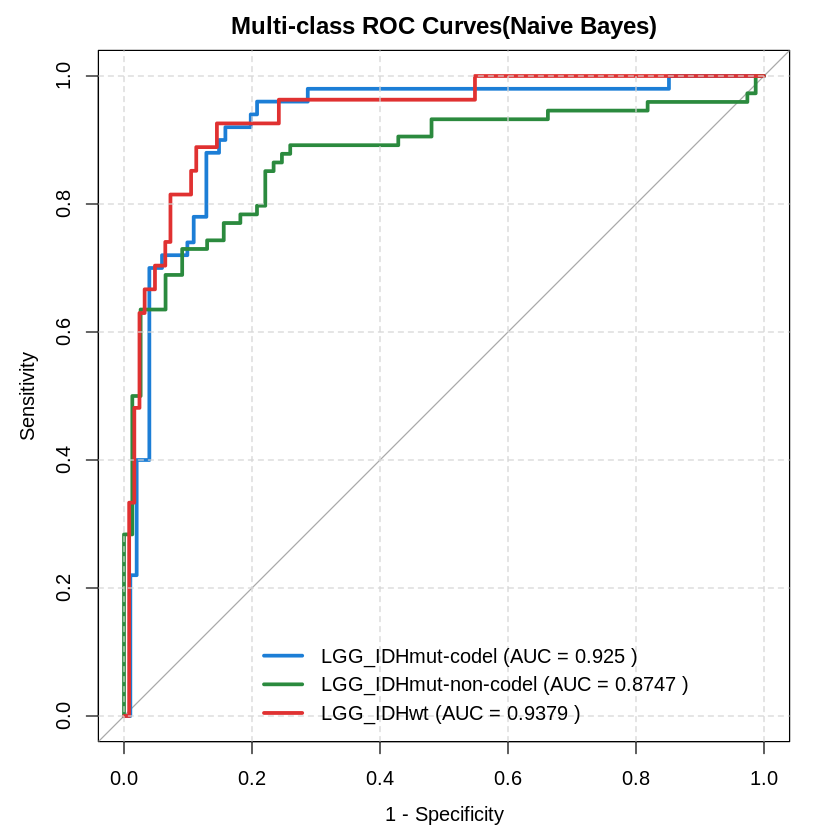

In [2]:
# ==============================================================================
# 1. 필수 패키지 설치 및 로드
# ==============================================================================
if(!require(naivebayes)) install.packages("naivebayes")
if(!require(caret)) install.packages("caret")
if(!require(dplyr)) install.packages("dplyr")

library(naivebayes)
library(caret)
library(dplyr)


# ==============================================================================
# 2. 데이터 불러오기
# ==============================================================================
data <- read.csv("/content/drive/MyDrive/융합정보의학 프로젝트/Data/1. Clinical Data/clinical_data.csv", sep = "\t", stringsAsFactors = TRUE, na.strings = c("", "NA"))


# ==============================================================================
# 3. 고도화된 데이터 전처리 (요청 사항 반영 구간)
# ==============================================================================
# 타겟 변수(SUBTYPE)의 결측치 제거 및 Factor 변환
data <- data[!is.na(data$SUBTYPE), ]
data$SUBTYPE <- as.factor(data$SUBTYPE)

# 과적합 및 노이즈 유발 식별자 / 행정용 변수 대거 제거
target_leakage_cols <- c(
  "PATIENT_ID", "OTHER_PATIENT_ID", "SAMPLE_ID", "FORM_COMPLETION_DATE",
  "CANCER_TYPE", "CANCER_TYPE_DETAILED", "CANCER_TYPE_ACRONYM", "ONCOTREE_CODE",
  "TISSUE_SOURCE_SITE", "TISSUE_SOURCE_SITE_CODE", "ICD_10", "ICD_O_3_SITE", "ICD_O_3_HISTOLOGY"
)
data_clean <- data[, !(names(data) %in% target_leakage_cols)]

# 결측치 비율이 30%를 초과하는 열(변수) 제거
max_na_ratio <- 0.3
high_na_cols <- sapply(data_clean, function(x) sum(is.na(x)) / length(x) > max_na_ratio)
data_clean <- data_clean[, !high_na_cols]


# 제로 분산(Zero-Variance) 노이즈 필터링
nzv <- nearZeroVar(data_clean)
if(length(nzv) > 0) {
  data_clean <- data_clean[, -nzv]
}

# 결측치를 R 기본 함수(중앙값/최빈값)로 안전하게 대체
for(i in 1:ncol(data_clean)) {
  if(is.numeric(data_clean[,i])) {
    data_clean[is.na(data_clean[,i]), i] <- median(data_clean[,i], na.rm = TRUE)
  } else if(is.factor(data_clean[,i])) {
    mod_val <- names(sort(table(data_clean[,i]), decreasing = TRUE))[1]
    data_clean[is.na(data_clean[,i]), i] <- mod_val
    data_clean[,i] <- factor(data_clean[,i]) # 빈 레벨 정리
  }
}


# ==============================================================================
# 4. 학습 및 테스트 데이터 분할 (7:3)
# ==============================================================================
set.seed(123)
train_index <- createDataPartition(data_clean$SUBTYPE, p = 0.7, list = FALSE)
train_data  <- data_clean[train_index, ]
test_data   <- data_clean[-train_index, ]


# ==============================================================================
# 5. 하이퍼파라미터 튜닝 그리드 설정
# ==============================================================================
train_control <- trainControl(method = "cv", number = 10, verboseIter = FALSE)
search_grid <- expand.grid(
  usekernel = c(TRUE, FALSE),
  laplace = c(0, 0.5, 1, 2),
  adjust = c(1)
)


# ==============================================================================
# 6. 최적화 모델 학습
# ==============================================================================
tuned_nb_model <- train(
  SUBTYPE ~ .,
  data = train_data,
  method = "naive_bayes",
  trControl = train_control,
  tuneGrid = search_grid
)

# 최적화 결과 확인
print(tuned_nb_model)


# ==============================================================================
# 7. 최종 검증 및 혼동 행렬
# ==============================================================================
final_pred <- predict(tuned_nb_model, newdata = test_data)
conf_matrix <- confusionMatrix(final_pred, test_data$SUBTYPE)
print(conf_matrix)


# ==============================================================================
# 8. ROC 커브 및 AUC 구하기
# ==============================================================================
if(!require(pROC)) install.packages("pROC")
library(pROC)

# 테스트 데이터에 대한 각 클래스별 확률 예측
pred_prob <- predict(tuned_nb_model, newdata = test_data, type = "prob")

# 다중 클래스(Multi-class)인 경우 모델 전체의 평균 AUC 확인
multi_roc <- multiclass.roc(test_data$SUBTYPE, pred_prob)
cat("\n--- Naive Bayes 전체 다중 클래스 평균 AUC ---\n")
print(multi_roc$auc)

# 클래스 이름 정의 (순서대로 지정)
class_names <- c("LGG_IDHmut-codel", "LGG_IDHmut-non-codel", "LGG_IDHwt")
colors <- c("#1c7ed6", "#2b8a3e", "#e03131") # 파랑, 초록, 빨강

# 2. 첫 번째 클래스(LGG_IDHmut-codel) ROC 커브 그리기 (기본 틀 생성)
actual_b1 <- ifelse(test_data$SUBTYPE == class_names[1], 1, 0)
roc1 <- roc(actual_b1, pred_prob[, class_names[1]])

plot(roc1,
     col = colors[1],
     lwd = 3,
     legacy.axes = TRUE,                                 # X축을 1-Specificity로 설정
     main = "Multi-class ROC Curves(Naive Bayes)")    # 그래프 제목

# 3. 두 번째 클래스(LGG_IDHmut-non-codel) 커브 겹쳐 그리기 (add = TRUE)
actual_b2 <- ifelse(test_data$SUBTYPE == class_names[2], 1, 0)
roc2 <- roc(actual_b2, pred_prob[, class_names[2]])
plot(roc2, col = colors[2], lwd = 3, add = TRUE)

# 4. 세 번째 클래스(LGG_IDHwt) 커브 겹쳐 그리기 (add = TRUE)
actual_b3 <- ifelse(test_data$SUBTYPE == class_names[3], 1, 0)
roc3 <- roc(actual_b3, pred_prob[, class_names[3]])
plot(roc3, col = colors[3], lwd = 3, add = TRUE)

# 5. 그래프 보조선(Grid) 추가
grid(col = "lightgray", lty = "dashed")

# 6. 우측 하단에 범례(Legend) 및 각 클래스별 AUC 점수 추가
legend("bottomright",
       legend = c(paste(class_names[1], "(AUC =", round(auc(roc1), 4), ")"),
                  paste(class_names[2], "(AUC =", round(auc(roc2), 4), ")"),
                  paste(class_names[3], "(AUC =", round(auc(roc3), 4), ")")),
       col = colors,
       lwd = 3,
       bty = "n") # 범례 테두리 선 제거

# Random Forest

Loading required package: randomForest

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘randomForest’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin





Call:
 randomForest(formula = SUBTYPE ~ ., data = train_data, ntree = 500,      importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 5

        OOB estimate of  error rate: 12.92%
Confusion matrix:
                     LGG_IDHmut-codel LGG_IDHmut-non-codel LGG_IDHwt
LGG_IDHmut-codel                  109                    7         1
LGG_IDHmut-non-codel                9                  158         7
LGG_IDHwt                           2                   20        43
                     class.error
LGG_IDHmut-codel      0.06837607
LGG_IDHmut-non-codel  0.09195402
LGG_IDHwt             0.33846154
Confusion Matrix and Statistics

                      Reference
Prediction             LGG_IDHmut-codel LGG_IDHmut-non-codel LGG_IDHwt
  LGG_IDHmut-codel                   47                    7         0
  LGG_IDHmut-non-codel                2                   63         7
  LGG_IDHwt    

Setting levels: control = 0, case = 1

Setting direction: controls < cases



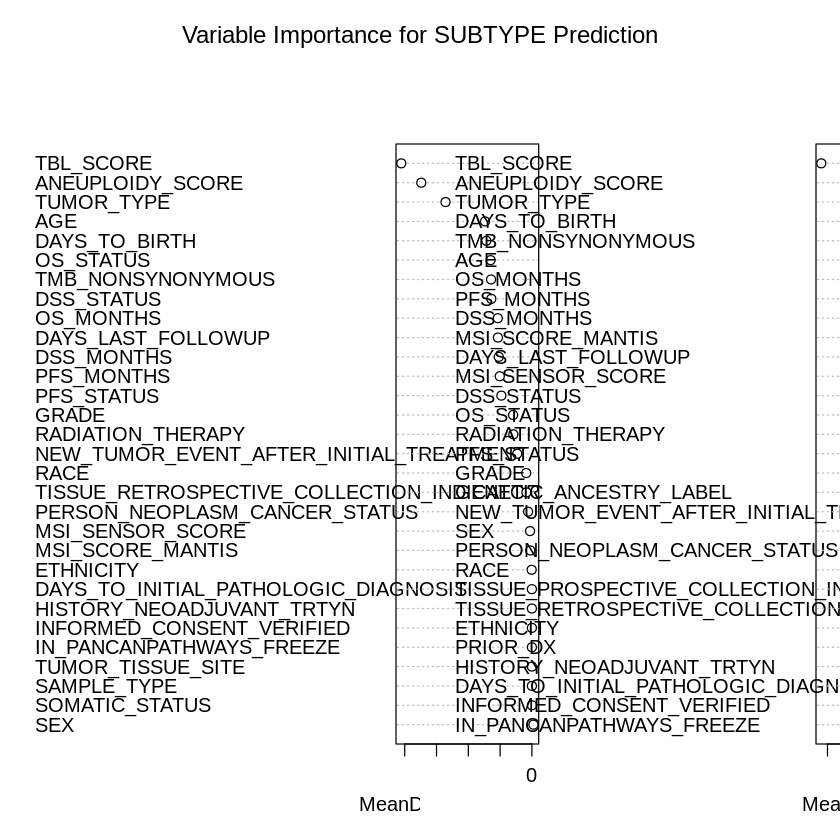

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



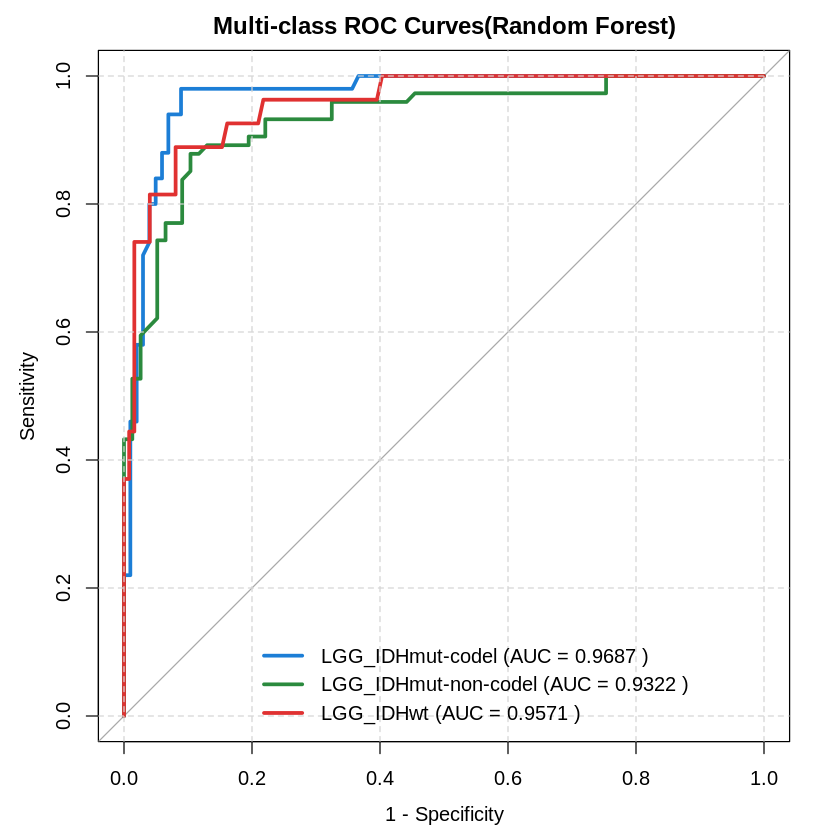

In [3]:
# 1. 필수 패키지 설치 및 로드
if(!require(randomForest)) install.packages("randomForest")
if(!require(caret)) install.packages("caret")
if(!require(pROC)) install.packages("pROC")
if(!require(dplyr)) install.packages("dplyr")

library(randomForest)
library(caret)
library(pROC)
library(dplyr)

# 2. 데이터 불러오기
data <- read.csv("/content/drive/MyDrive/융합정보의학 프로젝트/Data/1. Clinical Data/clinical_data.csv", sep = "\t", stringsAsFactors = TRUE, na.strings = c("", "NA"))

# 3. 데이터 전처리
data <- data[!is.na(data$SUBTYPE), ]
data$SUBTYPE <- as.factor(data$SUBTYPE)


# 제로 분산(Zero-Variance) 노이즈 필터링
nzv <- nearZeroVar(data_clean)
if(length(nzv) > 0) {
  data_clean <- data_clean[, -nzv]
}

# 과적합 및 노이즈 유발 식별자/행정 변수 제거
target_leakage_cols <- c(
  "PATIENT_ID", "OTHER_PATIENT_ID", "SAMPLE_ID", "FORM_COMPLETION_DATE", "CANCER_TYPE", "CANCER_TYPE_DETAILED", "CANCER_TYPE_ACRONYM", "ONCOTREE_CODE",
  "TISSUE_SOURCE_SITE", "TISSUE_SOURCE_SITE_CODE", "ICD_10", "ICD_O_3_SITE", "ICD_O_3_HISTOLOGY"
)
data_clean <- data[, !(names(data) %in% target_leakage_cols)]

# 결측치 비율이 30%를 초과하는 열(변수) 제거
max_na_ratio <- 0.3
high_na_cols <- sapply(data_clean, function(x) sum(is.na(x)) / length(x) > max_na_ratio)
data_clean <- data_clean[, !high_na_cols]


# 결측치를 R 기본 함수(중앙값/최빈값)로 안전하게 대체
for(i in 1:ncol(data_clean)) {
  if(is.numeric(data_clean[,i])) {
    data_clean[is.na(data_clean[,i]), i] <- median(data_clean[,i], na.rm = TRUE)
  } else if(is.factor(data_clean[,i])) {
    mod_val <- names(sort(table(data_clean[,i]), decreasing = TRUE))[1]
    data_clean[is.na(data_clean[,i]), i] <- mod_val
    data_clean[,i] <- factor(data_clean[,i])
  }
}


# 4. 학습 및 테스트 데이터 분할 (7:3, 시드 고정)
set.seed(123)
train_index <- createDataPartition(data_clean$SUBTYPE, p = 0.7, list = FALSE)
train_data  <- data_clean[train_index, ]
test_data   <- data_clean[-train_index, ]


# 5. Random Forest 모델 학습
# ntree = 500: 500개의 의사결정나무 배치
# importance = TRUE: 어떤 지표가 중요한지 변수 중요도 계산 수행
set.seed(123)
rf_model <- randomForest(SUBTYPE ~ ., data = train_data, ntree = 500, importance = TRUE)

# 모델 기본 요약 및 내장 OOB Error 확인
print(rf_model)


# 6. 최종 검증 (테스트 데이터 예측)
rf_pred <- predict(rf_model, newdata = test_data, type = "response")

# 혼동 행렬(Confusion Matrix) 출력 및 성능 평가
conf_matrix_rf <- confusionMatrix(rf_pred, test_data$SUBTYPE)
print(conf_matrix_rf)


# 7. 🔥 변수 중요도(Variable Importance) 확인 및 시각화
importance_values <- importance(rf_model)
varImpPlot(rf_model, main = "Variable Importance for SUBTYPE Prediction")


# 테스트 데이터에 대한 각 클래스별 '확률(Probability)' 예측값 추출
pred_prob <- predict(rf_model, newdata = test_data, type = "prob")

# 1) 다중 클래스(Multi-class) 모델 전체의 평균 AUC 계산 및 출력
multi_roc_rf <- multiclass.roc(test_data$SUBTYPE, pred_prob)
cat("\n--- Random Forest 전체 다중 클래스 평균 AUC ---\n")
print(multi_roc_rf$auc)


# 클래스 이름 정의 (순서대로 지정)
class_names <- c("LGG_IDHmut-codel", "LGG_IDHmut-non-codel", "LGG_IDHwt")
colors <- c("#1c7ed6", "#2b8a3e", "#e03131") # 파랑, 초록, 빨강

# 2. 첫 번째 클래스(LGG_IDHmut-codel) ROC 커브 그리기 (기본 틀 생성)
actual_b1 <- ifelse(test_data$SUBTYPE == class_names[1], 1, 0)
roc1 <- roc(actual_b1, pred_prob[, class_names[1]])

plot(roc1,
     col = colors[1],
     lwd = 3,
     legacy.axes = TRUE,                 # X축을 1-Specificity로 설정
     main = "Multi-class ROC Curves(Random Forest)")    # 그래프 제목

# 3. 두 번째 클래스(LGG_IDHmut-non-codel) 커브 겹쳐 그리기 (add = TRUE)
actual_b2 <- ifelse(test_data$SUBTYPE == class_names[2], 1, 0)
roc2 <- roc(actual_b2, pred_prob[, class_names[2]])
plot(roc2, col = colors[2], lwd = 3, add = TRUE)

# 4. 세 번째 클래스(LGG_IDHwt) 커브 겹쳐 그리기 (add = TRUE)
actual_b3 <- ifelse(test_data$SUBTYPE == class_names[3], 1, 0)
roc3 <- roc(actual_b3, pred_prob[, class_names[3]])
plot(roc3, col = colors[3], lwd = 3, add = TRUE)

# 5. 그래프 보조선(Grid) 추가
grid(col = "lightgray", lty = "dashed")

# 6. 우측 하단에 범례(Legend) 및 각 클래스별 AUC 점수 추가
legend("bottomright",
       legend = c(paste(class_names[1], "(AUC =", round(auc(roc1), 4), ")"),
                  paste(class_names[2], "(AUC =", round(auc(roc2), 4), ")"),
                  paste(class_names[3], "(AUC =", round(auc(roc3), 4), ")")),
       col = colors,
       lwd = 3,
       bty = "n") # 범례 테두리 선 제거



# Logistic Regression

Penalized Multinomial Regression 

356 samples
 25 predictor
  3 classes: 'LGG_IDHmut-codel', 'LGG_IDHmut-non-codel', 'LGG_IDHwt' 

No pre-processing
Resampling: None 
Confusion Matrix and Statistics

                      Reference
Prediction             LGG_IDHmut-codel LGG_IDHmut-non-codel LGG_IDHwt
  LGG_IDHmut-codel                   45                   11         1
  LGG_IDHmut-non-codel                4                   53         6
  LGG_IDHwt                           1                   10        20

Overall Statistics
                                         
               Accuracy : 0.7815         
                 95% CI : (0.707, 0.8445)
    No Information Rate : 0.4901         
    P-Value [Acc > NIR] : 1.807e-13      
                                         
                  Kappa : 0.6552         
                                         
 Mcnemar's Test P-Value : 0.2341         

Statistics by Class:

                     Class: LGG_IDHmut-codel Class: LGG_IDHmut

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



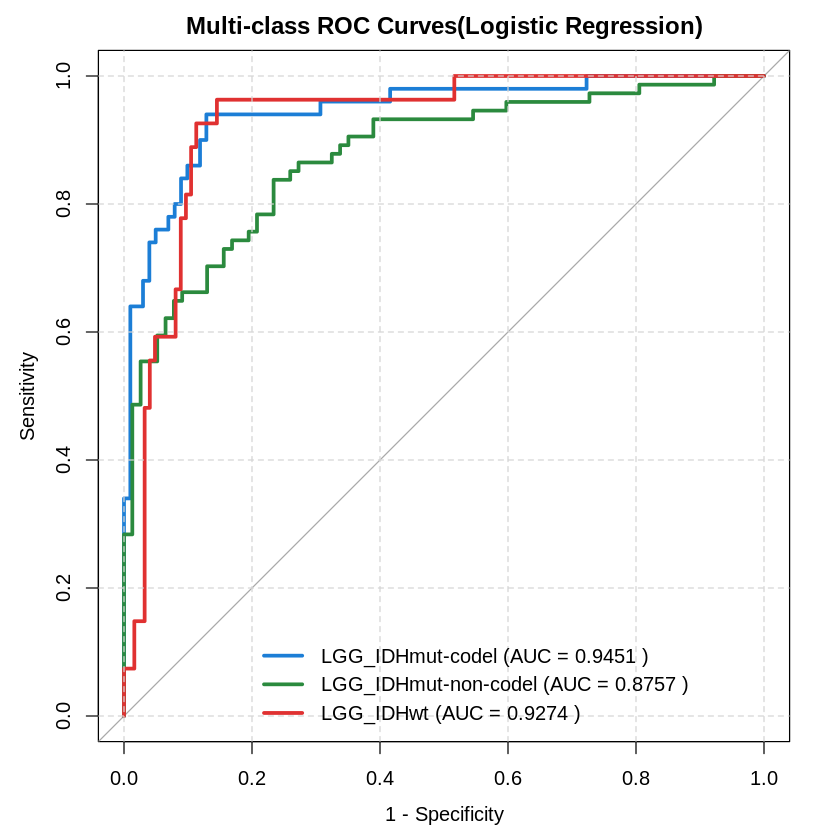

In [ ]:
# ==============================================================================
# 1. 필수 패키지 설치 및 로드
# ==============================================================================
if(!require(nnet)) install.packages("nnet")
if(!require(caret)) install.packages("caret")
if(!require(pROC)) install.packages("pROC")
if(!require(dplyr)) install.packages("dplyr")

library(nnet)
library(caret)
library(pROC)
library(dplyr)


# ==============================================================================
# 2. 데이터 로드 및 기본 정제
# ==============================================================================
data <- read.csv("/content/drive/MyDrive/융합정보의학 프로젝트/Data/1. Clinical Data/clinical_data.csv", sep = "\t", stringsAsFactors = TRUE, na.strings = c("", "NA"))

# 타겟 변수(SUBTYPE)의 결측치 제거 및 Factor 변환
data <- data[!is.na(data$SUBTYPE), ]
data$SUBTYPE <- as.factor(data$SUBTYPE)


# ==============================================================================
# 3. 과적합 및 오류 유발 변수 제거
# ==============================================================================
# 과적합 및 오류 유발 식별자 / 행정용 변수 대거 제거
target_leakage_cols <- c(
  "PATIENT_ID", "OTHER_PATIENT_ID", "SAMPLE_ID", "FORM_COMPLETION_DATE",
  "CANCER_TYPE", "CANCER_TYPE_DETAILED", "CANCER_TYPE_ACRONYM", "ONCOTREE_CODE",
  "TISSUE_SOURCE_SITE", "TISSUE_SOURCE_SITE_CODE", "ICD_10", "ICD_O_3_SITE", "ICD_O_3_HISTOLOGY"
)
data_clean <- data[, !(names(data) %in% target_leakage_cols)]


# 제로 분산(Zero-Variance) 노이즈 필터링
nzv <- nearZeroVar(data_clean)
if(length(nzv) > 0) {
  data_clean <- data_clean[, -nzv]
}

# 결측치 비율이 30%를 초과하는 열(변수) 제거
max_na_ratio <- 0.3
high_na_cols <- sapply(data_clean, function(x) sum(is.na(x)) / length(x) > max_na_ratio)
data_clean <- data_clean[, !high_na_cols]

# 결측치를 R 기본 함수(중앙값/최빈값)로 안전하게 대체
for(i in 1:ncol(data_clean)) {
  if(is.numeric(data_clean[,i])) {
    data_clean[is.na(data_clean[,i]), i] <- median(data_clean[,i], na.rm = TRUE)
  } else if(is.factor(data_clean[,i])) {
    mod_val <- names(sort(table(data_clean[,i]), decreasing = TRUE))[1]
    data_clean[is.na(data_clean[,i]), i] <- mod_val
    data_clean[,i] <- factor(data_clean[,i])
  }
}


# ==============================================================================
# 4. 로지스틱 회귀를 위한 가더미화 및 스케일링 전처리
# ==============================================================================
# 1) 범주형 변수를 가더미(One-hot) 수치 형태로 변환
dummies <- dummyVars(" ~ .", data = data_clean[, names(data_clean) != "SUBTYPE"], fullRank = TRUE)
X_dummy <- predict(dummies, newdata = data_clean[, names(data_clean) != "SUBTYPE"])

# 2) 변환된 데이터 전체에 대해 평균 0, 분산 1 정규화 적용
preProc_steps <- preProcess(X_dummy, method = c("center", "scale"))
X_transformed <- predict(preProc_steps, newdata = X_dummy)

# 3) 타겟 변수(SUBTYPE)와 결합하여 최종 모델용 데이터프레임 생성
final_dataset <- data.frame(SUBTYPE = data_clean$SUBTYPE, X_transformed)


# ==============================================================================
# 5. 학습 데이터 및 테스트 데이터 분할 (7:3)
# ==============================================================================
set.seed(123)
train_index <- createDataPartition(final_dataset$SUBTYPE, p = 0.7, list = FALSE)
train_data  <- final_dataset[train_index, ]
test_data   <- final_dataset[-train_index, ]


# ==============================================================================
# 6. 단일 로지스틱 회귀 모델 학습 (코드 내 오타 수정 완료)
# ==============================================================================
train_control_none <- trainControl(method = "none")
single_grid <- expand.grid(decay = 0.01)

set.seed(123)
lr_model <- train(
  SUBTYPE ~ .,
  data = train_data,
  method = "multinom",
  trControl = train_control_none,
  tuneGrid = single_grid,
  trace = FALSE
)
print(lr_model)


# ==============================================================================
# 7. 독립 테스트 데이터를 통한 최종 성능 검증 (Confusion Matrix)
# ==============================================================================
final_pred <- predict(lr_model, newdata = test_data)
conf_matrix <- confusionMatrix(final_pred, test_data$SUBTYPE)
print(conf_matrix)


# ==============================================================================
# 8. ROC 커브 및 AUC 구하기
# ==============================================================================
# 테스트 데이터에 대한 각 클래스별 '확률(Probability)' 예측값 추출
pred_prob <- predict(lr_model, newdata = test_data, type = "prob")

# 1) 다중 클래스(Multi-class) 모델 전체의 평균 AUC 계산 및 출력
multi_roc_rf <- multiclass.roc(test_data$SUBTYPE, pred_prob)
cat("\n--- Logistic Regression 전체 다중 클래스 평균 AUC ---\n")
print(multi_roc_rf$auc)


# 클래스 이름 정의 (순서대로 지정)
class_names <- c("LGG_IDHmut-codel", "LGG_IDHmut-non-codel", "LGG_IDHwt")
colors <- c("#1c7ed6", "#2b8a3e", "#e03131") # 파랑, 초록, 빨강

# 2. 첫 번째 클래스(LGG_IDHmut-codel) ROC 커브 그리기 (기본 틀 생성)
actual_b1 <- ifelse(test_data$SUBTYPE == class_names[1], 1, 0)
roc1 <- roc(actual_b1, pred_prob[, class_names[1]])

plot(roc1,
     col = colors[1],
     lwd = 3,
     legacy.axes = TRUE,                                 # X축을 1-Specificity로 설정
     main = "Multi-class ROC Curves(Logistic Regression)")    # 그래프 제목

# 3. 두 번째 클래스(LGG_IDHmut-non-codel) 커브 겹쳐 그리기 (add = TRUE)
actual_b2 <- ifelse(test_data$SUBTYPE == class_names[2], 1, 0)
roc2 <- roc(actual_b2, pred_prob[, class_names[2]])
plot(roc2, col = colors[2], lwd = 3, add = TRUE)

# 4. 세 번째 클래스(LGG_IDHwt) 커브 겹쳐 그리기 (add = TRUE)
actual_b3 <- ifelse(test_data$SUBTYPE == class_names[3], 1, 0)
roc3 <- roc(actual_b3, pred_prob[, class_names[3]])
plot(roc3, col = colors[3], lwd = 3, add = TRUE)

# 5. 그래프 보조선(Grid) 추가
grid(col = "lightgray", lty = "dashed")

# 6. 우측 하단에 범례(Legend) 및 각 클래스별 AUC 점수 추가
legend("bottomright",
       legend = c(paste(class_names[1], "(AUC =", round(auc(roc1), 4), ")"),
                  paste(class_names[2], "(AUC =", round(auc(roc2), 4), ")"),
                  paste(class_names[3], "(AUC =", round(auc(roc3), 4), ")")),
       col = colors,
       lwd = 3,
       bty = "n") # 범례 테두리 선 제거